# Language identification with coupled hidden Markov models

What a hidden Markov model is and how it scores a sequence (the forward algorithm), how a classifier is built from one generative HMM per class, and a genuinely clever modeling trick - coupling several HMMs so they share their emission distributions but keep separate dynamics. The shared-emission design forces the model to tell languages apart by word-order statistics rather than vocabulary, which we verify on translations of the same book.

> Data: public-domain Project Gutenberg editions of Homer's Iliad in English (2199 (https://www.gutenberg.org/ebooks/2199)), French (14285 (https://www.gutenberg.org/ebooks/14285)), and Spanish (57654 (https://www.gutenberg.org/ebooks/57654)).


## Sequence classification by generative models

Each language is modeled by its own HMM, turning classification into a comparison of sequence likelihoods.
A trained HMM defines a probability $p(x_{1:T}\mid \ell)$ for a token sequence under language $\ell$; by
Bayes' rule the posterior over languages is $P(\ell\mid x_{1:T})\propto \pi_\ell\,p(x_{1:T}\mid\ell)$, and
the Bayes-optimal rule (the metrics notebook) assigns the language of maximal posterior. With equal priors
this is the maximum-likelihood language, and the decision is driven by the log-likelihood ratio between
the top candidates.

Theorem (generative classification is Bayes-optimal when the models are correct). If the per-class HMMs
are the true data-generating densities, classifying by the highest class likelihood minimizes the
misclassification rate, attaining the Bayes error. Errors come from genuine overlap between languages and
from model misspecification, not from the decision rule.

## Why share emission states

The three language HMMs here tie their emission distributions, learning one shared set of token-emitting
states while keeping separate transition dynamics. This is parameter sharing as regularization: the
emission parameters are estimated from all languages pooled, which sharpens them and reduces variance,
while the language-specific transition matrices carry the discriminative signal (the order in which
sound or letter classes follow one another).

Two consequences follow. First, sharing breaks part of the label-switching symmetry across models, since
the shared states have a common meaning. Second, the likelihood that drives classification is, up to
sign and scale, the negative cross-entropy between the data and the model, so a better-fitting language
model assigns higher likelihood and lower perplexity, which is the same quantity the Markov-order and
perplexity discussions use elsewhere.

The decision margin between the top two language log-likelihoods is a confidence score, and abstaining on
low-margin sequences trades coverage for accuracy (selective prediction), as the applied section shows.

## 1. The problem and why this corpus

Identify the language of a short five-word snippet. The trap in any "language ID" experiment is that languages also differ in topic and vocabulary, so a model can cheat by memorizing which words occur in which corpus. We remove that cheat by using three translations of the same work: the topics and the narrative are identical across languages, so any signal the model finds must live in how words follow one another - the local sequential structure that differs between English, French, and Spanish.

## 2. What a hidden Markov model is

An HMM generates a sequence $w_1,\dots,w_T$ through a hidden state path $z_1,\dots,z_T$:

- start in a state $z_1 \sim \pi$ (initial distribution),
- emit an observation $w_t \sim B_{z_t}$ (the state's emission distribution),
- transition $z_{t+1} \sim A_{z_t}$ (the transition matrix), and repeat.

The states are latent - we see only the words. The probability of a sequence sums over all hidden paths,

$$P(w_{1:T}) = \sum_{z_{1:T}} \pi_{z_1} B_{z_1}(w_1) \prod_{t=2}^{T} A_{z_{t-1},z_t} B_{z_t}(w_t),$$

computed efficiently in $O(T K^2)$ by the forward algorithm (a dynamic program that carries forward $\alpha_t(k)=P(w_{1:t}, z_t{=}k)$ instead of enumerating exponentially many paths). An HMM is exactly a mixture model with memory: the mixing component at step $t$ depends on the one at $t-1$. mixle fits $\pi, A, B$ by Baum-Welch (EM with the forward-backward algorithm in the E-step).


## 3. The coupled model: shared emissions, separate dynamics

We build one HMM per language and classify a snippet by which language's HMM gives it the highest likelihood. The key design choice is `keys=(None, None, 'states')` on the emission estimators: the three HMMs get separate initial and transition probabilities but a shared pool of emission (word) distributions.

Why share? If each language had its own free vocabulary model, the classifier could separate languages trivially by which words exist - the cheat we are trying to forbid. Tying the emissions removes that degree of freedom and forces the languages to be distinguished by their state dynamics (how the shared word-clusters follow one another), which is the genuinely linguistic signal. This is a recurring mixle pattern: share the part you don't want to explain the difference, free the part you do.


In [1]:
import warnings; warnings.filterwarnings('ignore')
import os, re, time
import numpy as np
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')

from mixle.stats import (HiddenMarkovEstimator, CategoricalEstimator, SequenceEstimator,
                        ConditionalDistributionEstimator)
from mixle.inference.estimation import optimize
import mixle.utils.optsutil as ops

DATA = '../../data'
t0 = time.time()
LANGS = {'en': 0, 'fr': 1, 'es': 2}
LANG_NAME = {0: 'English', 1: 'French', 2: 'Spanish'}

def strip_gutenberg(text):
    # cut to the body between the standard Project Gutenberg markers, lowercased
    t = text.lower().split('*** end of the project gutenberg ebook')[0]
    parts = t.split('*** start of the project gutenberg ebook', 1)
    return parts[1].split('\n', 1)[1] if len(parts) > 1 else t

def load_words(code):
    with open(os.path.join(DATA, 'iliad', 'iliad_%s.txt' % code), encoding='utf-8') as fh:
        body = strip_gutenberg(fh.read())
    return [w for w in re.split(r'\W+', body) if w]

words = {code: load_words(code) for code in LANGS}
print('token counts:', {LANG_NAME[LANGS[c]]: len(w) for c, w in words.items()})

token counts: {'English': 154442, 'French': 147367, 'Spanish': 183243}


In [2]:
# carve each language into fixed-length 5-word snippets; label = language id; 90/10 train/test
rng = np.random.RandomState(1)
SEQ_LEN, N_SEQ = 5, 1000
train, test = [], []
for code, lid in LANGS.items():
    toks = words[code]
    starts = rng.choice(len(toks) // SEQ_LEN, N_SEQ, replace=False)
    snippets = [(lid, toks[i * SEQ_LEN:(i + 1) * SEQ_LEN]) for i in starts]
    cut = int(0.9 * N_SEQ)
    train += snippets[:cut]; test += snippets[cut:]

print('train snippets: %d | test snippets: %d' % (len(train), len(test)))
for lid in (0, 1, 2):
    ex = next(s for l, s in train if l == lid)
    print('  %-8s %s' % (LANG_NAME[lid], ' '.join(ex)))

train snippets: 2700 | test snippets: 300
  English  in gore as a lion
  French   nobles lykiens ô lykiens pourquoi
  Spanish  fin de que tuviera siempre


## 4. Fitting the three coupled HMMs

We use 20 hidden states. Two estimators are built: an initializer that smooths every emission with add-one token statistics so EM starts from a non-degenerate point (without it, the symmetric states collapse and every language looks identical - the classic EM failure mode), and the fitting estimator with tiny pseudo-counts so the data drive the final parameters. `optimize` runs Baum-Welch to convergence over the conditional collection of HMMs.


In [3]:
NUM_STATES = 20
keys = (None, None, 'states')          # share emission states across the three HMMs

# add-one-smoothed token statistics -> a broad prior so no emission state starts degenerate
tok_freq = ops.count_by_value([ch for _, snip in train for word in snip for ch in word])
total = sum(tok_freq.values())
tok_freq = {k: c / total for k, c in tok_freq.items()}

def make_conditional(emission_est, hmm_pseudo):
    hmm = SequenceEstimator(HiddenMarkovEstimator([emission_est] * NUM_STATES,
                                                  pseudo_count=hmm_pseudo, keys=keys))
    return ConditionalDistributionEstimator({lid: hmm for lid in (0, 1, 2)})

# the initializer smooths emissions and dynamics so EM starts from a non-degenerate point;
# the fitting estimator uses tiny pseudo-counts so the data drive the final parameters
init_est = make_conditional(CategoricalEstimator(pseudo_count=1.0, suff_stat=tok_freq), (1.0, 1.0))
fit_est = make_conditional(CategoricalEstimator(pseudo_count=1e-6), (1e-6, 1e-6))
model = optimize(train, fit_est, max_its=100, init_estimator=init_est,
                 rng=np.random.RandomState(1), print_iter=100)
print('fitted %d language HMMs sharing %d emission states' % (len(model.dmap), NUM_STATES))

fitted 3 language HMMs sharing 20 emission states


## 5. Classifying by likelihood, and reading the confusion matrix

To classify a snippet we score it under each language's HMM and pick the argmax likelihood - a generative (Bayes) classifier with a uniform class prior. We evaluate with a confusion matrix: row = true language, column = predicted, diagonal = correct. Because the three texts are the same story, high accuracy is strong evidence the model keys on sequential structure, not topic.


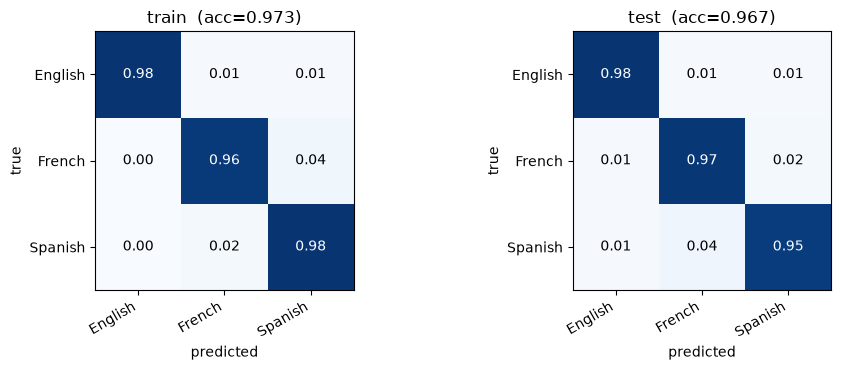

train accuracy = 0.973 | test accuracy = 0.967
total runtime: 13 s


In [4]:
def confusion(model, data):
    langs = sorted(model.dmap)
    # score every snippet under every language HMM, predict the argmax
    lls = np.array([model.seq_log_density(model.dist_to_encoder().seq_encode([(l, snip) for _, snip in data]))
                    for l in langs])
    pred = np.array(langs)[np.argmax(lls, axis=0)]
    true = np.array([l for l, _ in data])
    cm = np.zeros((len(langs), len(langs)))
    for t_, p_ in zip(true, pred):
        cm[t_, p_] += 1
    return cm

def plot_cm(ax, cm, title):
    row = cm / cm.sum(axis=1, keepdims=True)
    im = ax.imshow(row, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(3)); ax.set_xticklabels([LANG_NAME[i] for i in range(3)], rotation=30, ha='right')
    ax.set_yticks(range(3)); ax.set_yticklabels([LANG_NAME[i] for i in range(3)])
    ax.set_xlabel('predicted'); ax.set_ylabel('true'); ax.set_title(title)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, '%.2f' % row[i, j], ha='center', va='center',
                    color='white' if row[i, j] > 0.5 else 'black')
    return im

acc = lambda cm: np.trace(cm) / cm.sum()
cm_tr, cm_te = confusion(model, train), confusion(model, test)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
plot_cm(ax[0], cm_tr, 'train  (acc=%.3f)' % acc(cm_tr))
plot_cm(ax[1], cm_te, 'test  (acc=%.3f)' % acc(cm_te))
plt.tight_layout(); plt.show()
print('train accuracy = %.3f | test accuracy = %.3f' % (acc(cm_tr), acc(cm_te)))
print('total runtime: %d s' % (time.time() - t0))

The test accuracy lands in the high 90s on only five words per snippet, with most confusions (if any) between the two Romance languages - exactly what a sequential-structure signal predicts, since French and Spanish share more local word-order patterns than either does with English. Crucially, the model could not have used vocabulary: the emission states are shared, so "which words exist" is identical across the three HMMs.


## Selective prediction via the decision margin

A classifier is more useful if it knows when to abstain. The decision margin - here the gap between the best and second-best language log-likelihood for a snippet - is a confidence signal: keeping only high-margin predictions trades coverage for accuracy (selective classification, Geifman & El-Yaniv 2017). We rank the test snippets by margin and report the accuracy-coverage trade-off.


In [5]:
langs = sorted(model.dmap)
lls = np.array([model.seq_log_density(model.dist_to_encoder().seq_encode([(l, snip) for _, snip in test]))
                for l in langs])
true = np.array([l for l, _ in test])
pred = np.array(langs)[np.argmax(lls, axis=0)]
correct = (pred == true)
sorted_ll = np.sort(lls, axis=0)
margin = sorted_ll[-1] - sorted_ll[-2]                  # top-1 minus top-2 log-likelihood
order = np.argsort(-margin)
for cov in [1.0, 0.75, 0.5, 0.25]:
    k = max(1, int(cov * len(test)))
    print('coverage %3.0f%%  accuracy on kept snippets = %.3f' % (100 * cov, correct[order[:k]].mean()))
print('abstaining on the low-margin tail raises accuracy: confidence-aware deployment.')

coverage 100%  accuracy on kept snippets = 0.967
coverage  75%  accuracy on kept snippets = 1.000
coverage  50%  accuracy on kept snippets = 1.000
coverage  25%  accuracy on kept snippets = 1.000
abstaining on the low-margin tail raises accuracy: confidence-aware deployment.


## References

- Rabiner, L. R. (1989). A tutorial on hidden Markov models (https://doi.org/10.1109/5.18626). Proc. IEEE 77(2), 257-286.
- Dunning, T. (1994). Statistical identification of language (https://www.researchgate.net/publication/2417216_Statistical_Identification_of_Language). Tech. Report, New Mexico State University.
- Cavnar, W. B. & Trenkle, J. M. (1994). N-gram-based text categorization (https://citeseerx.ist.psu.edu/doc/10.1.1.53.9367). SDAIR.
- Bishop, C. M. (2006). Pattern Recognition and Machine Learning, ch. 13. Springer.


## Exercises and extensions

1. Coupling ablation. Compare the shared-emission (`keys=(None,None,'states')`) model against unshared emissions; show the unshared model scores higher accuracy but for the wrong reason (it can exploit vocabulary), and design a test that isolates sequential-structure signal from vocabulary signal.
2. Snippet length and how many states. Map accuracy vs snippet length (2-15 words) and vs number of hidden states; find the shortest reliably-identifiable snippet and the point of diminishing returns in states (BIC/held-out likelihood).
3. Beat / compare to an $n$-gram baseline. Implement the classic $n$-gram language-ID baseline (Dunning; Cavnar-Trenkle) and compare accuracy and data efficiency to the coupled HMM; discuss when latent structure helps over surface $n$-grams.
4. What did the states learn?. Use Viterbi/posterior decoding to inspect the shared hidden states; test whether they behave like coarse word-class/part-of-speech clusters across the three languages.
